# Customer Churn — Exploratory Data Analysis (EDA)
**Kaggle Playground Series - S6E3**

### Goal
Understand the structure of the data, the severity of class imbalance, and which features are most predictive of churn — all framed as business questions, not just statistical observations.

In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

TRAIN_PATH = '../data/raw/train.csv'
TEST_PATH  = '../data/raw/test.csv'

# Colors scheme for plots
binary_colors = ['#9e9fa3', '#d16060']

# No gridlines for cleaner look
plt.rcParams['axes.grid'] = False

## 1. Load & Inspect

In [71]:
from src.preprocessing import load_data, encode_target

train, test = load_data(TRAIN_PATH, TEST_PATH)
train['Churn_bin'] = encode_target(train['Churn'])

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
train.head(3)

Train shape : (594194, 22)
Test shape  : (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,0


In [72]:
train.dtypes.to_frame('dtype').assign(nunique=train.nunique())

,dtype,nunique
id,int64,594194
gender,object,2
SeniorCitizen,int64,2
Partner,object,2
Dependents,object,2
tenure,int64,72
PhoneService,object,2
MultipleLines,object,3
InternetService,object,3
OnlineSecurity,object,3


In [73]:
train.describe(include='all')

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
count,594194.00,594194,594194.00,594194,594194,594194.00,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194.00,594194.00,594194,594194.00
unique,NaN,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2,NaN
top,NaN,Female,NaN,Yes,No,NaN,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,NaN,NaN,No,NaN
freq,NaN,298738,NaN,309554,414362,NaN,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,NaN,NaN,460377,NaN
mean,297096.50,NaN,0.11,NaN,NaN,36.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.87,2494.38,NaN,0.23
std,171529.18,NaN,0.32,NaN,NaN,25.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.07,2353.92,NaN,0.42
min,0.00,NaN,0.00,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,18.80,NaN,0.00
25%,148548.25,NaN,0.00,NaN,NaN,12.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.90,639.65,NaN,0.00
50%,297096.50,NaN,0.00,NaN,NaN,35.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.10,1433.65,NaN,0.00
75%,445644.75,NaN,0.00,NaN,NaN,62.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.80,4263.80,NaN,0.00


## 2. Numeric Feature Distributions

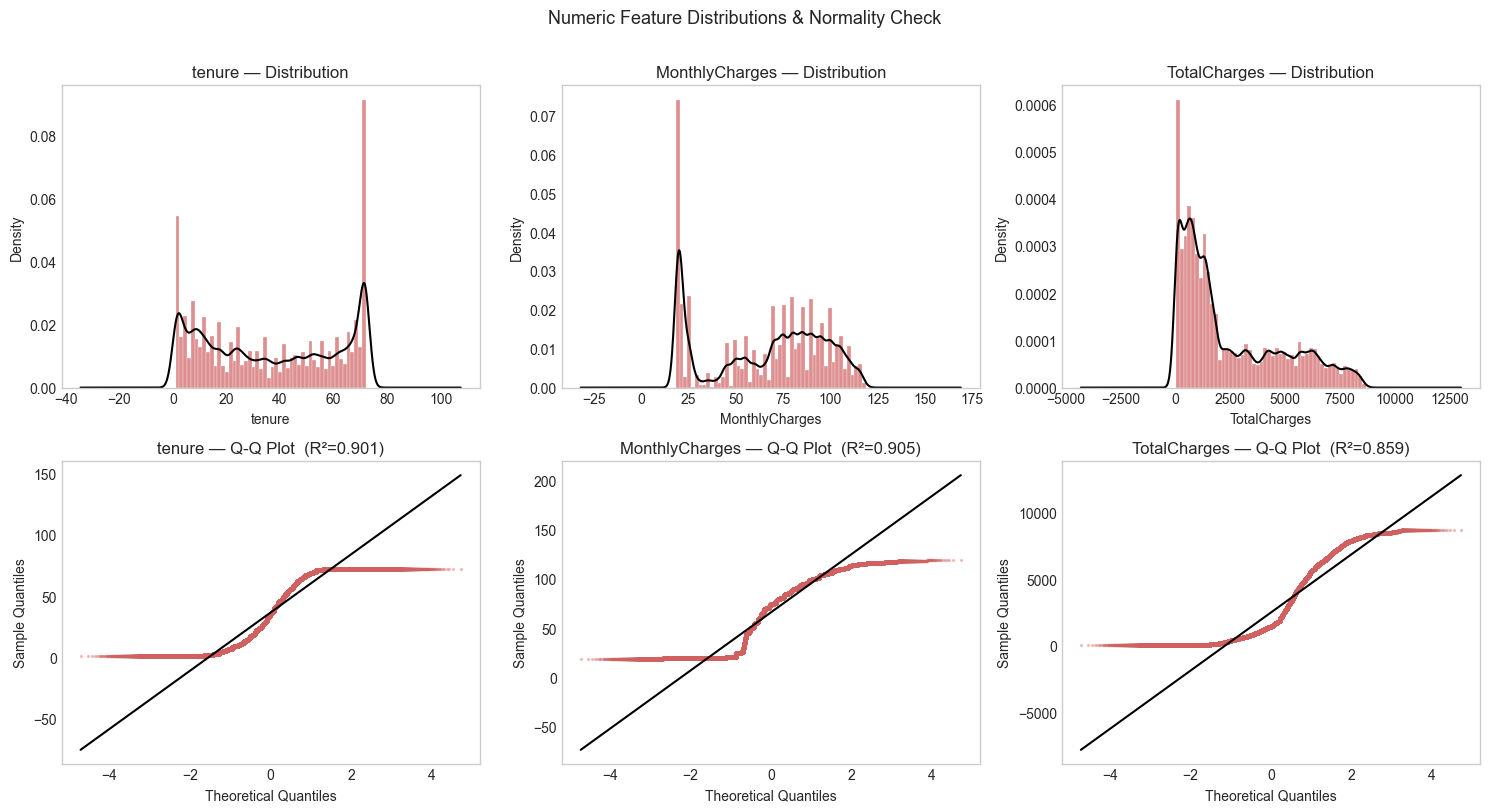

Feature                  Mean        Std   Skewness   Kurtosis
------------------------------------------------------------
tenure                  36.58      25.06      0.063     -1.487
MonthlyCharges          65.87      31.07     -0.289     -1.278
TotalCharges          2494.38    2353.92      0.909     -0.446


In [74]:
from scipy import stats

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    data = train[col].dropna()

    # Row 0: histogram + KDE
    axes[0, i].hist(data, bins=50, color=binary_colors[0], alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
    data.plot.kde(ax=axes[0, i], color='black', linewidth=1.5)
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Density')

    # Row 1: Q-Q plot
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    axes[1, i].scatter(osm, osr, color=binary_colors[0], alpha=0.3, s=2)
    axes[1, i].plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.5)
    axes[1, i].set_title(f'{col} — Q-Q Plot  (R²={r**2:.3f})')
    axes[1, i].set_xlabel('Theoretical Quantiles')
    axes[1, i].set_ylabel('Sample Quantiles')

plt.suptitle('Numeric Feature Distributions & Normality Check', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_distributions.png', dpi=150)
plt.show()

# Summary stats: skewness and kurtosis
print(f"{'Feature':<18} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}")
print('-' * 60)
for col in num_cols:
    data = train[col].dropna()
    print(f"{col:<18} {data.mean():>10.2f} {data.std():>10.2f} "
          f"{data.skew():>10.3f} {data.kurt():>10.3f}")

**Insights**:
- **tenure**: Roughly uniform — customers are spread fairly evenly across contract ages, with slight peaks at 1 month (new customers) and 72 months (loyal customers). Not normally distributed.
- **MonthlyCharges**: Bimodal — a low-charge cluster (~20–30, likely basic plans) and a high-charge cluster (~70–100, premium/fiber plans). Skewed distribution confirms that StandardScaler (not log transform) is sufficient since tree models are scale-invariant.
- **TotalCharges**: Right-skewed — driven by `tenure × MonthlyCharges`. Many new customers with low totals pull the distribution right. The Q-Q plot confirms non-normality, which is expected for a compound variable.

## 3. Missing Values & Data Quality

In [75]:
# Check for missing values
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

print(f'Missing values in train:')
print(missing_train[missing_train > 0])
print(f'\nMissing values in test:')
print(missing_test[missing_test > 0])

Missing values in train:
Series([], dtype: int64)

Missing values in test:
Series([], dtype: int64)


In [76]:
# Check for duplicates
duplicates_train = train.duplicated().sum()
duplicates_test = test.duplicated().sum()

print(f'Duplicates in train: {duplicates_train}')
print(f'Duplicates in test: {duplicates_test}')

Duplicates in train: 0
Duplicates in test: 0


**COMMENT:**

There are no missing values and duplication in either dataset.

## 4. Target Variable Distribution

Class imbalance is critical to understand before choosing a modeling strategy.

Churn distribution:
        count  pct%
Churn              
No     460377 77.50
Yes    133817 22.50


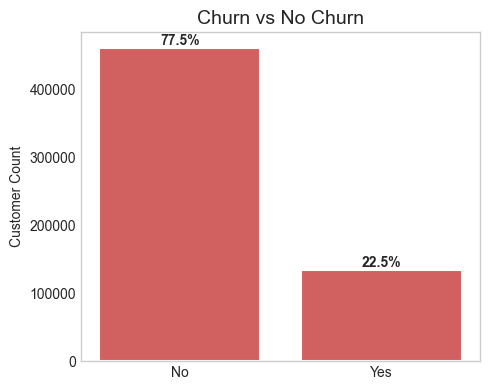

In [77]:
churn_counts = train['Churn'].value_counts()
churn_pct    = train['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
print(pd.concat([churn_counts, churn_pct.round(1)], axis=1,
                keys=['count', 'pct%']))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(churn_counts.index, churn_counts.values,
              color= binary_colors, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Churn vs No Churn', fontsize=14)
ax.set_ylabel('Customer Count')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../data/processed/fig_churn_distribution.png')
plt.show()

**Insight**: The dataset is moderately imbalanced (~77.5% No / ~22.5% Yes).

## 5. Univariate Analysis — Key Features

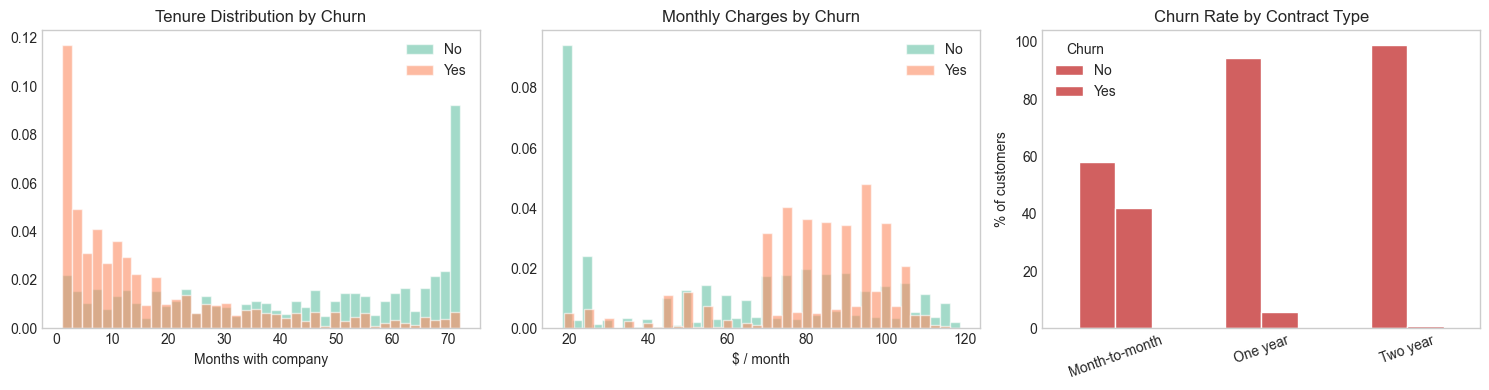

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure
for label, grp in train.groupby('Churn'):
    axes[0].hist(grp['tenure'], bins=40, alpha=0.6, label=label, density=True)
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Months with company')
axes[0].legend()

# Monthly Charges
for label, grp in train.groupby('Churn'):
    axes[1].hist(grp['MonthlyCharges'], bins=40, alpha=0.6, label=label, density=True)
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xlabel('$ / month')
axes[1].legend()

# Contract type
contract_churn = (train.groupby(['Contract', 'Churn'])
                       .size()
                       .unstack(fill_value=0)
                       .apply(lambda r: r / r.sum() * 100, axis=1))
contract_churn.plot(kind='bar', ax=axes[2], color= binary_colors,
                    edgecolor='white', linewidth=1)
axes[2].set_title('Churn Rate by Contract Type')
axes[2].set_ylabel('% of customers')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='Churn')

plt.tight_layout()
plt.savefig('../data/processed/fig_univariate.png', dpi=150)
plt.show()

**Insights**:
- **Tenure**: Churners cluster heavily in the first 12 months. Customers who survive past ~24 months are much less likely to churn. Retention efforts should front-load value in the first year.
- **Monthly Charges**: Churners tend to have higher monthly bills. High-value customers are the most at risk — doubly important to retain.
- **Contract Type**: Month-to-month contracts churn at dramatically higher rates than 1- or 2-year contracts. The single most powerful intervention is converting customers to longer-term contracts.

## 6. Categorical Features — Churn Rates

In [ ]:
cat_cols = [
    'InternetService', 'PaymentMethod', 'TechSupport',
    'OnlineSecurity', 'StreamingTV', 'MultipleLines'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = (train.groupby(col)['Churn_bin']
                       .mean()
                       .sort_values(ascending=False) * 100)
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                        color=binary_colors[1])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_categorical_churn.png', dpi=150)
plt.show()

## 7. Correlation Heatmap (Numeric Features)

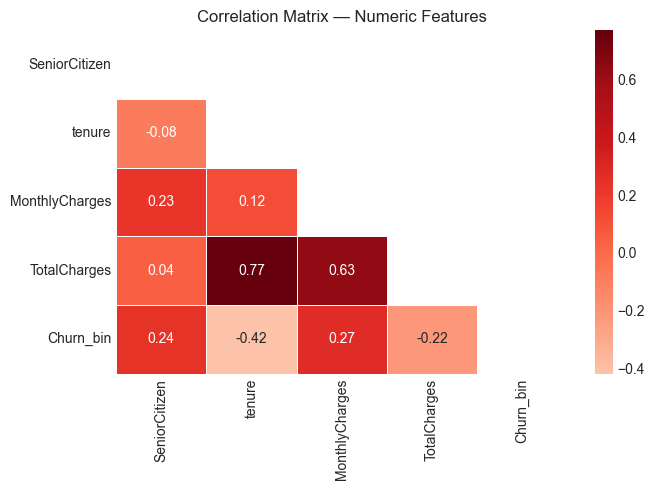

In [80]:
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Reds',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../data/processed/fig_correlation.png', dpi=150)
plt.show()

C:\Users\ryand\AppData\Local\Temp\ipykernel_10592\1844210011.py:4: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Churn', y=col, data=train, ax=axes[i//2, i%2], palette=binary_colors, hue='Churn', legend=False)
C:\Users\ryand\AppData\Local\Temp\ipykernel_10592\1844210011.py:4: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Churn', y=col, data=train, ax=axes[i//2, i%2], palette=binary_colors, hue='Churn', legend=False)
C:\Users\ryand\AppData\Local\Temp\ipykernel_10592\1844210011.py:4: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Churn', y=col, data=train, ax=axes[i//2, i%2], palette=binary_colors, hue='Churn', legend=False)
C:\Users\ryand\AppData\Local\Temp\ipykernel_10592\1844210011.py:4: UserWarni

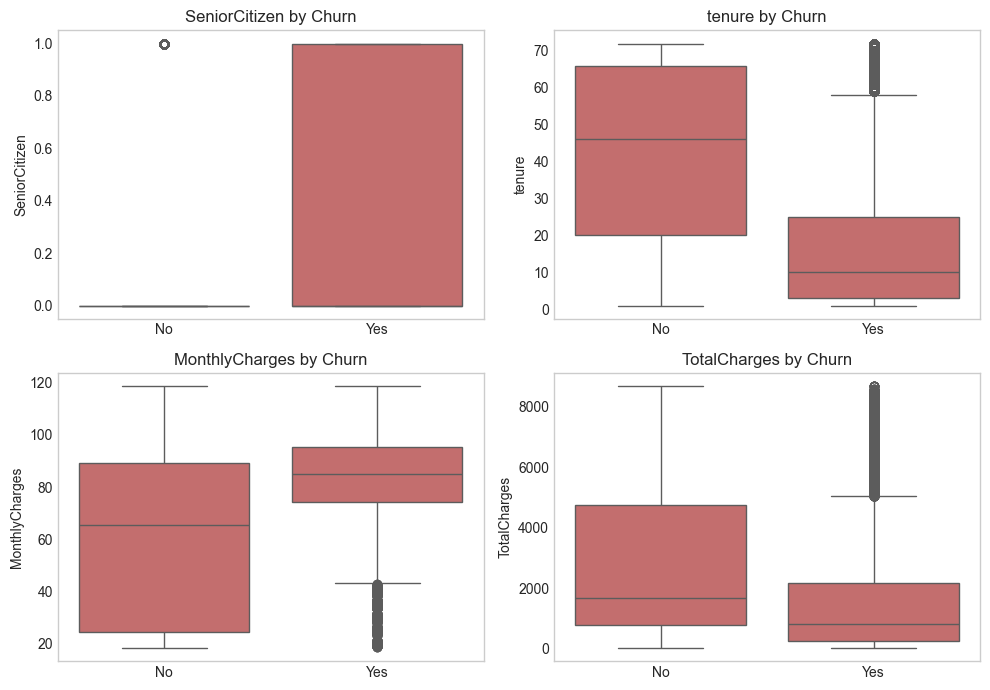

In [81]:
# Boxplot of Numeric Features by Churn
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i, col in enumerate(numeric_cols[:-1]):
    sns.boxplot(x='Churn', y=col, data=train, ax=axes[i//2, i%2], palette=binary_colors, hue='Churn', legend=False)
    axes[i//2, i%2].set_title(f'{col} by Churn')
    axes[i//2, i%2].set_xlabel('')
    axes[i//2, i%2].grid(False)
plt.tight_layout()
plt.savefig('../data/processed/fig_boxplots.png', dpi=150)
plt.show()

## 8. Variance Inflation Factor (VIF)

High VIF (>10) indicates multicollinearity that can destabilise logistic regression coefficients.

In [82]:
vif_data = train[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].dropna()

vif_df = pd.DataFrame({
    'Feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i)
            for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_df.to_string(index=False))
print('\nVIF > 10 = potentially problematic multicollinearity')

       Feature  VIF
  TotalCharges 7.22
        tenure 5.24
MonthlyCharges 3.90
 SeniorCitizen 1.21

VIF > 10 = potentially problematic multicollinearity


**Insight**: If VIF is high, consider dropping `TotalCharges` for logistic regression. For XGBoost this is less of a concern — tree models handle correlated features gracefully.

## 9. Key Business Takeaways

| Finding | Business Implication |
|---|---|
| ~27% churn rate | 1 in 4 customers leaves — industry avg is ~15–25%, so this is elevated |
| Churn spikes in month 1–12 | Onboarding experience is critical; consider a 90-day check-in program |
| High monthly charges → higher churn | High-value customers are most at risk; prioritise them for retention offers |
| Month-to-month contracts churn 3–4x more | Annual contract discounts have the highest ROI of any retention lever |
| Fiber optic customers churn more | Possible service quality or price perception issue worth investigating |
| No OnlineSecurity / TechSupport → higher churn | Bundling add-ons increases stickiness and reduces churn |

### Modeling Implications
- **Contract type** and **tenure** will likely be the strongest predictors — expect them near the top of feature importance rankings
- Moderate class imbalance (~27% churn) → use `class_weight='balanced'` for logistic regression, `scale_pos_weight` for XGBoost
- Multicollinearity between `tenure` and `TotalCharges` → monitor for logistic regression; safe to keep both for tree models
- Evaluate with **ROC-AUC** (competition metric) but also track **cost-weighted accuracy** for business relevance